In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PROJECT_PATH = "/content/drive/MyDrive/NLP_Project"

In [4]:
import os

os.makedirs(PROJECT_PATH + "/data", exist_ok=True)
os.makedirs(PROJECT_PATH + "/results", exist_ok=True)
os.makedirs(PROJECT_PATH + "/src", exist_ok=True)

print("Project folders created")

Project folders created


In [5]:
!pip install nltk

In [6]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
data_dict = {
    "text":[
        "I love this movie",
        "This movie is terrible",
        "Amazing film",
        "I hate this movie",
        "This movie is fantastic",
        "This movie is boring",
        "I really like this film",
        "Worst movie ever",
        "Great story and acting",
        "Very bad movie"
    ],

    "sentiment":[
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative"
    ]
}

data = pd.DataFrame(data_dict)

data.to_csv(PROJECT_PATH + "/data/movie_reviews.csv", index=False)

data.head()

,text,sentiment
0,I love this movie,positive
1,This movie is terrible,negative
2,Amazing film,positive
3,I hate this movie,negative
4,This movie is fantastic,positive


In [9]:
data = pd.read_csv(PROJECT_PATH + "/data/movie_reviews.csv")

data.head()

,text,sentiment
0,I love this movie,positive
1,This movie is terrible,negative
2,Amazing film,positive
3,I hate this movie,negative
4,This movie is fantastic,positive


In [10]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

data["clean_text"] = data["text"].apply(clean_text)

data.head()

,text,sentiment,clean_text
0,I love this movie,positive,love movie
1,This movie is terrible,negative,movie terrible
2,Amazing film,positive,amazing film
3,I hate this movie,negative,hate movie
4,This movie is fantastic,positive,movie fantastic


In [11]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(data["clean_text"])

y = data["sentiment"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [14]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.5


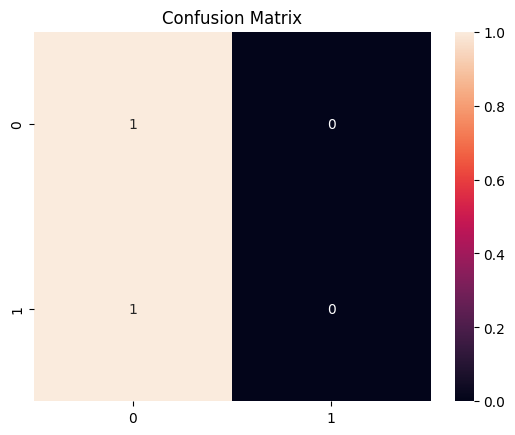

In [16]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")

plt.savefig(PROJECT_PATH + "/results/confusion_matrix.png")

plt.show()

In [17]:
test_text = ["this movie is amazing"]

test_clean = [clean_text(t) for t in test_text]

test_vector = vectorizer.transform(test_clean)

prediction = model.predict(test_vector)

print("Prediction:", prediction)

Prediction: ['positive']
